# Data Validation & Data Quality Checks

This lecture covers:
- **Data Validation:** Checking data types, missing values, and basic consistency.
- **Outlier Detection:** Using boxplots and the IQR method.
- **Identifying Inconsistencies & Errors:** Spotting duplicates and unexpected values.

In [3]:
import pandas as pd  # For data manipulation
import numpy as np  # For numerical operations
import seaborn as sns  # For easy dataset loading and visualizations
import matplotlib.pyplot as plt  # For plotting
from scipy.stats import iqr  # For getting the iqr

## Load the Dataset

We'll use the **tips** dataset from seaborn, with an appended row containing negative values to simulate errors.

In [4]:
df = sns.load_dataset("tips")
# Appending a negative tip
df.loc[-1] = [-25, -5, "Male", "Yes", "Jan", "Midnight", 30]

## 1. Data Validation

### Data Overview

First few rows of the dataset:

In [7]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Data Types & Missing Values

Data Types:

In [10]:
df.dtypes

total_bill    float64
tip           float64
sex            object
smoker         object
day            object
time           object
size            int64
dtype: object

Missing Values per Column:

In [11]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

## 2. Detecting Outliers

### Boxplot for Selected Column

Change the `column` variable below to explore different numeric columns (e.g., `"total_bill"`, `"tip"`, `"size"`).

<Axes: xlabel='tip'>

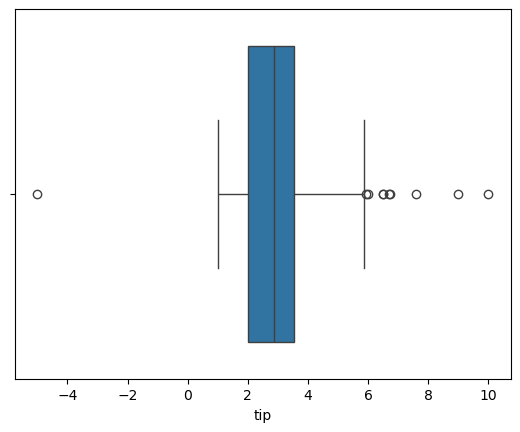

In [9]:
column = 'tip'

sns.boxplot(x = df[column])

### IQR Method for Outlier Detection

Calculate the IQR to identify outliers:

In [13]:
# Compute Q1 and Q3 using numpy
Q1, Q3 = np.percentile(df[column].dropna(), [25, 75])
IQR = iqr(df[column].dropna())

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")

# Identify outliers
outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
print(f"\nRows with outliers in '{column}':")
outliers

Lower Bound: -0.32
Upper Bound: 5.88

Rows with outliers in 'tip':


,total_bill,tip,sex,smoker,day,time,size
23,39.42,7.58,Male,No,Sat,Dinner,4
47,32.40,6.00,Male,No,Sun,Dinner,4
59,48.27,6.73,Male,No,Sat,Dinner,4
141,34.30,6.70,Male,No,Thur,Lunch,6
170,50.81,10.00,Male,Yes,Sat,Dinner,3
183,23.17,6.50,Male,Yes,Sun,Dinner,4
212,48.33,9.00,Male,No,Sat,Dinner,4
214,28.17,6.50,Female,Yes,Sat,Dinner,3
239,29.03,5.92,Male,No,Sat,Dinner,3
-1,-25.00,-5.00,Male,Yes,Jan,Midnight,30


## 3. Identifying Inconsistencies and Errors

### Duplicate Records

In [14]:
# Check for duplicate rows in the dataset
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
df[df.duplicated() == 1]

Number of duplicate rows: 1


,total_bill,tip,sex,smoker,day,time,size
202,13.0,2.0,Female,Yes,Thur,Lunch,2


### Checking for Unexpected Values in 'tip'

A negative tip value would be an error — let's check for those.

In [ ]:
# Check for negative tip values
negative_tips = df[df["tip"] < 0]
if negative_tips.empty:
    print("No negative tip values found.")
else:
    print("Negative tip values detected:")
    display(negative_tips)

## Conclusion

Validating your data is a crucial first step in any analysis.  
By checking for data type mismatches, missing values, outliers, duplicates,  
and other inconsistencies, you can ensure that your insights are based on reliable data.